In [15]:
import matplotlib.pyplot as plt
from src.TimeSeriesAnalysis import *
from IPython.display import clear_output
plt.style.use('properties.mplstyle')
from matplotlib.ticker import AutoMinorLocator, MultipleLocator
from matplotlib.lines import Line2D
from src.process_data import run_processing_data
from IPython.display import clear_output
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

In [2]:
results_folder = "../results/TimeSeries/3D"
create_folder(results_folder)

In [3]:
run_processing_data(base_root="../Data", force_recompute=False, burn_in=0.20, verbose=True)
clear_output()

In [4]:
TYPE_PERC = "bond"
NUM_COLORS = 4
DIM = 3
L = 512
NT = 26000
K = 8.0e-07
RHO = 1.0e-03
P0_LIST = [0.30, 0.70, 1.00]

compute_means_for_folder(
    type_perc=TYPE_PERC,
    num_colors=NUM_COLORS,
    dim=DIM,
    L=L,
    NT=NT,
    k=K,
    rho=RHO,
    p0_list=P0_LIST,
)

[ok] p0=0.30: 100 arquivos agregados
[ok] p0=0.70: 100 arquivos agregados
[ok] p0=1.00: 100 arquivos agregados
[salvo] ../Data/bond_percolation/num_colors_4/dim_3/L_512/NT_constant/NT_26000/k_8.0e-07/rho_1.0000e-03/properties_mean_bundle.json


'../Data/bond_percolation/num_colors_4/dim_3/L_512/NT_constant/NT_26000/k_8.0e-07/rho_1.0000e-03/properties_mean_bundle.json'

In [5]:
bundle_path = "../Data/bond_percolation/num_colors_4/dim_3/L_512/NT_constant/NT_26000/k_8.0e-07/rho_1.0000e-03/properties_mean_bundle.json"
bundle, p0_index = load_bundle(bundle_path)
for keys in p0_index[0.3][1]:
    print(keys)

time
pt
nt
Mt
Smax
Ni
chi
stats


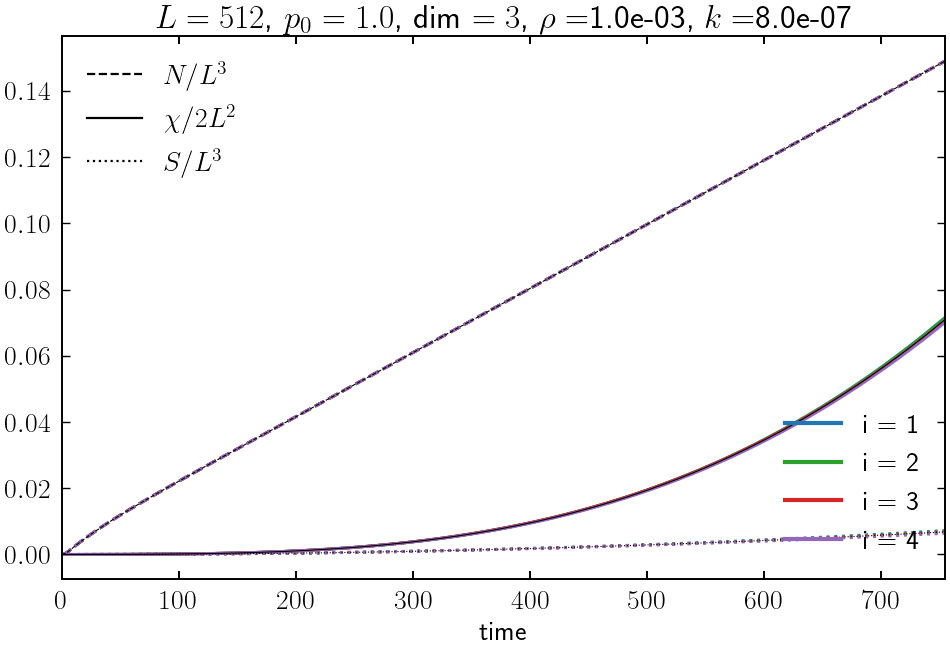

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===== params =====
orders = [1,2,3,4]
p0 = 1.0
L, dim = 512, 3
VOL  = L**dim
AREA = L**(dim-1)


# ===== util =====
def series(key, name):  # pega e já trunca depois
    return np.asarray(p0_index[p0][key][name], dtype=float)

# tamanhos mínimos (garante mesmo comprimento para média/preto)
St  = min(len(series(k,'Smax')) for k in orders)
Nt  = min(len(series(k,'Ni'))   for k in orders)
Ct  = min(len(series(k,'chi'))  for k in orders)
Tt  = min(len(series(k,'time')) for k in orders)
Tmin = min(St, Nt, Ct, Tt)

# ===== plot =====
fig, ax = plt.subplots(figsize=(10,7))

colors = ['C0','C2','C3','C4']   # 4 cores para i=1..4
for j, key in enumerate(orders):
    t   = series(key,'time')[:Tmin]
    S   = series(key,'Smax')[:Tmin] / VOL
    N   = series(key,'Ni')  [:Tmin] / VOL
    chi = series(key,'chi') [:Tmin] / (2*AREA)

    # sanity: S ≤ N sempre
    assert np.all(S <= N), f"S>N para ordem {key}; verifique os dados."

    # linhas coloridas (somente legenda de cores)
    lbl = f"i = {key}"
    ax.plot(t, S,   linestyle=':',  color=colors[j], linewidth=2.1, label=lbl)
    ax.plot(t, N,   linestyle='--', color=colors[j], linewidth=2.1)
    ax.plot(t, chi, linestyle='-',  color=colors[j], linewidth=2.1)

# ===== linhas pretas “guia” (média entre ordens) =====
# empilha e faz média ponto a ponto
t   = series(orders[0],'time')[:Tmin]
S_M = np.mean([series(k,'Smax')[:Tmin]/VOL         for k in orders], axis=0)
N_M = np.mean([series(k,'Ni')  [:Tmin]/VOL         for k in orders], axis=0)
C_M = np.mean([series(k,'chi') [:Tmin]/(2*AREA)    for k in orders], axis=0)

ax.plot(t, N_M, linestyle='--', color='k', linewidth=.8)
ax.plot(t, C_M, linestyle='-',  color='k', linewidth=.8)
ax.plot(t, S_M, linestyle=':',  color='k', linewidth=.8)


# ===== legendas no estilo do artigo =====
style_handles = [
    Line2D([0],[0], color='k', linestyle='--',  linewidth=1.6, label=r'$N/L^{{{}}}$'.format(dim)),
    Line2D([0],[0], color='k', linestyle='-', linewidth=1.6, label=r'$\chi/2L^{{{}}}$'.format(dim-1)),
    Line2D([0],[0], color='k', linestyle=':',  linewidth=1.6, label=r'$S/L^{{{}}}$'.format(dim)),
]
color_handles = [Line2D([0],[0], color=colors[j], linewidth=3, label=f'i = {orders[j]}')
                 for j in range(len(orders))]

leg1 = ax.legend(handles=style_handles, loc='upper left', frameon=False)
ax.add_artist(leg1)
ax.legend(handles=color_handles, loc='lower right', frameon=False, title=None)

# ===== acabamento =====
ax.set_xlabel('time')
ax.set_ylabel('')  # sem label no y, como você pediu
ax.set_xlim(t.min(), t.max())
ax.tick_params(direction='in', top=True, right=True)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.set_title(f"$L = {L}$, $p_0 = {p0}$, dim $= {dim}$, $\\rho = ${RHO:.1e}, $k = ${K:.1e}")
#ax.set_ylim([0.0, 0.25])
plt.tight_layout()

plt.savefig(results_folder + "/EvolutionProperties_time.pdf")
plt.show()

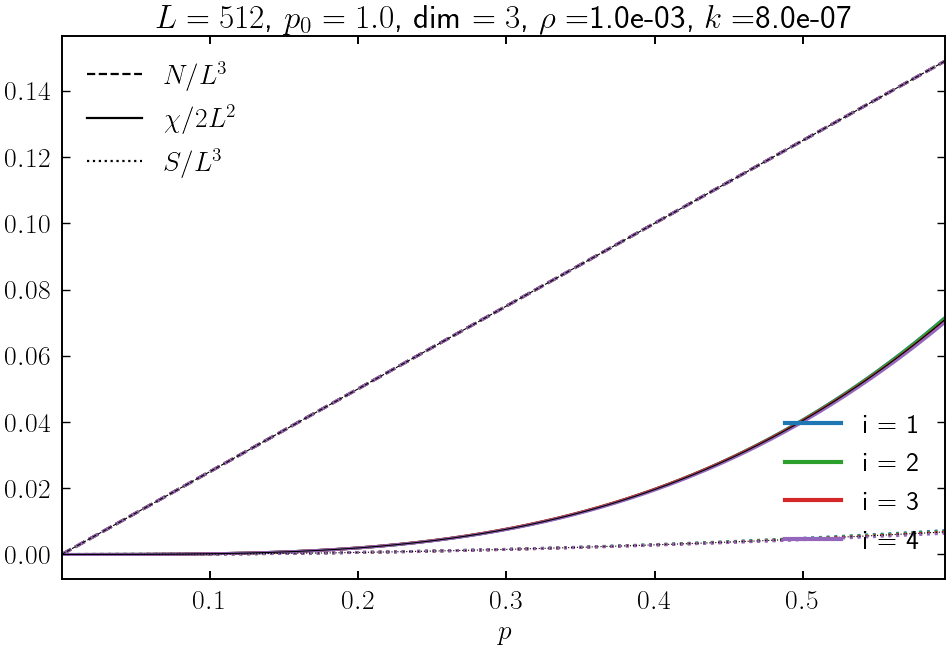

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# ===== params =====
orders = [1,2,3,4]
p0 = 1.0
L, dim = 512, 3
VOL  = L**dim
AREA = L**(dim-1)

# ===== util =====
def series(key, name):  # pega e já trunca depois
    return np.asarray(p0_index[p0][key][name], dtype=float)

# tamanhos mínimos (garante mesmo comprimento para média/preto)
St  = min(len(series(k,'Smax')) for k in orders)
Nt  = min(len(series(k,'Ni'))   for k in orders)
Ct  = min(len(series(k,'chi'))  for k in orders)
Tt  = min(len(series(k,'time')) for k in orders)
Tmin = min(St, Nt, Ct, Tt)

# ===== p(t) global (soma sobre as cores) =====
# p(t) = (sum_i N_i(t)) / VOL
N_stack = np.stack([series(k, 'Ni')[:Tmin] for k in orders], axis=0)  # shape: (n_orders, Tmin)
p = N_stack.sum(axis=0) / VOL                                        # shape: (Tmin,)

# ===== plot =====
fig, ax = plt.subplots(figsize=(10,7))

colors = ['C0','C2','C3','C4']   # 4 cores para i=1..4

for j, key in enumerate(orders):
    # eixo x agora é p(t), comum a todas as curvas
    x   = p
    S   = series(key,'Smax')[:Tmin] / VOL
    N   = series(key,'Ni')  [:Tmin] / VOL
    chi = series(key,'chi') [:Tmin] / (2*AREA)

    # sanity: S ≤ N sempre
    assert np.all(S <= N), f"S>N para ordem {key}; verifique os dados."

    # linhas coloridas (somente legenda de cores)
    lbl = f"i = {key}"
    ax.plot(x, S,   linestyle=':',  color=colors[j], linewidth=2.1, label=lbl)
    ax.plot(x, N,   linestyle='--', color=colors[j], linewidth=2.1)
    ax.plot(x, chi, linestyle='-',  color=colors[j], linewidth=2.1)

# ===== linhas pretas “guia” (média entre ordens) =====
S_M = np.mean([series(k,'Smax')[:Tmin]/VOL         for k in orders], axis=0)
N_M = np.mean([series(k,'Ni')  [:Tmin]/VOL         for k in orders], axis=0)
C_M = np.mean([series(k,'chi') [:Tmin]/(2*AREA)    for k in orders], axis=0)

ax.plot(p, N_M, linestyle='--', color='k', linewidth=.8)
ax.plot(p, C_M, linestyle='-',  color='k', linewidth=.8)
ax.plot(p, S_M, linestyle=':',  color='k', linewidth=.8)

# ===== legendas no estilo do artigo =====
style_handles = [
    Line2D([0],[0], color='k', linestyle='--', linewidth=1.6, label=r'$N/L^{{{}}}$'.format(dim)),
    Line2D([0],[0], color='k', linestyle='-',  linewidth=1.6, label=r'$\chi/2L^{{{}}}$'.format(dim-1)),
    Line2D([0],[0], color='k', linestyle=':',  linewidth=1.6, label=r'$S/L^{{{}}}$'.format(dim)),
]
color_handles = [Line2D([0],[0], color=colors[j], linewidth=3, label=f'i = {orders[j]}')
                 for j in range(len(orders))]

leg1 = ax.legend(handles=style_handles, loc='upper left', frameon=False)
ax.add_artist(leg1)
ax.legend(handles=color_handles, loc='lower right', frameon=False, title=None)

# ===== acabamento =====
ax.set_xlabel(r'$p$'.format(dim))
ax.set_ylabel('')  # sem label no y
# como p está em [0,1] (fração), os limites ficam naturais:
ax.set_xlim(p.min(), p.max())
ax.tick_params(direction='in', top=True, right=True)
ax.spines['top'].set_visible(True)
ax.spines['right'].set_visible(True)
ax.set_title(f"$L = {L}$, $p_0 = {p0}$, dim $= {dim}$, $\\rho = ${RHO:.1e}, $k = ${K:.1e}")
# ax.set_ylim([0.0, 0.25])

plt.tight_layout()
plt.savefig(results_folder + "/EvolutionProperties_p.pdf")
plt.show()


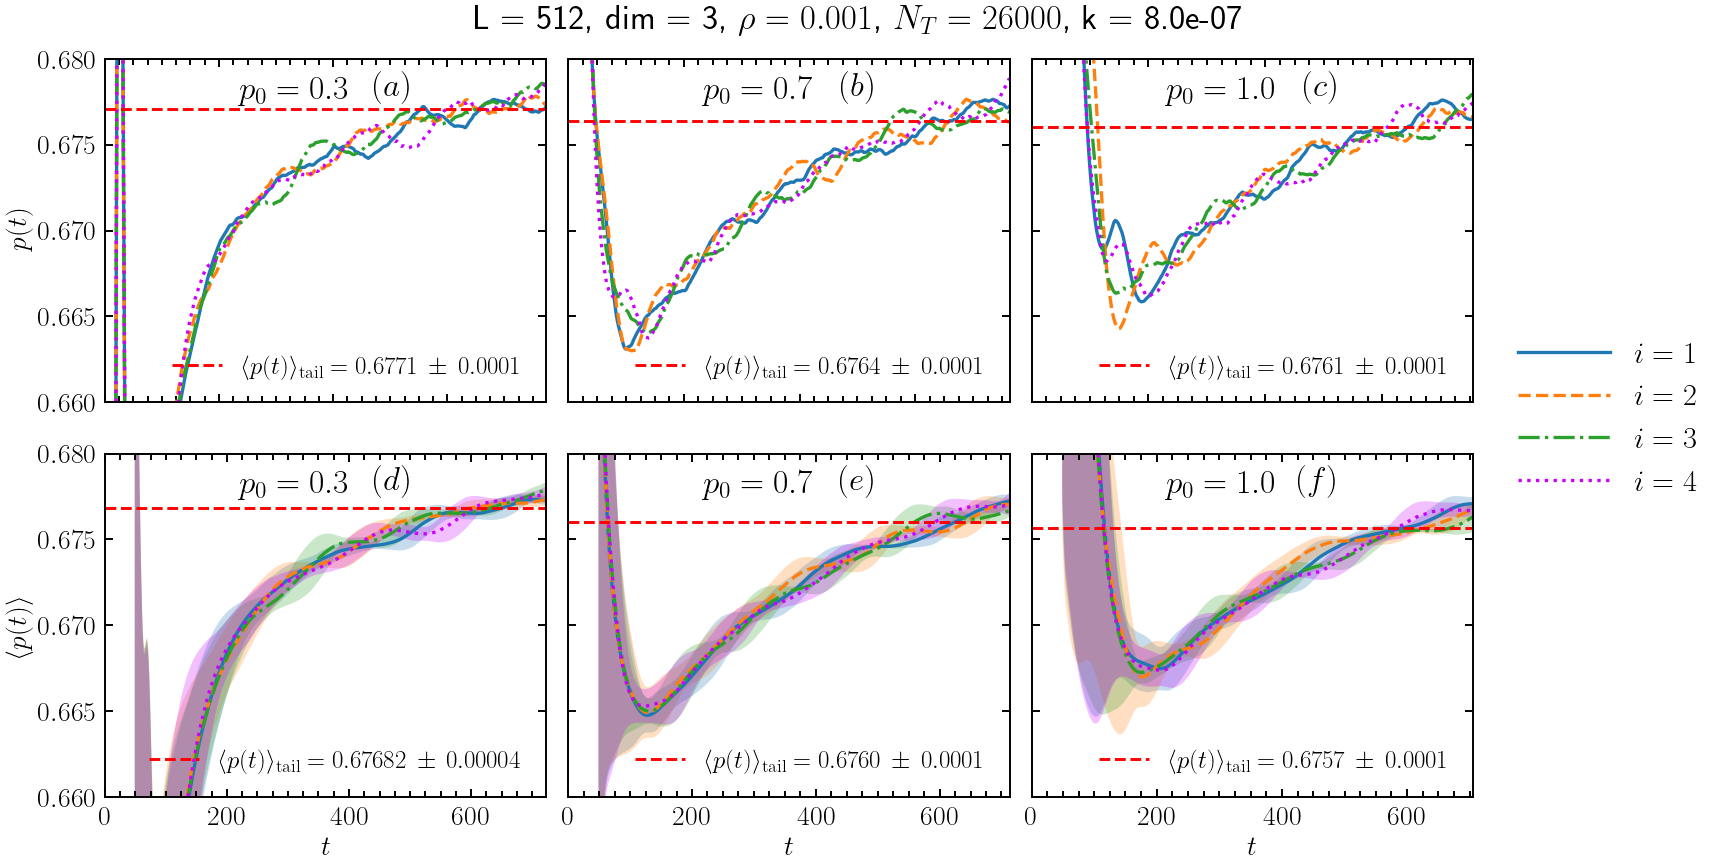

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ================== helpers ==================
def tail_mean(arr, tail_frac=0.3):
    a = np.asarray(arr, dtype=float)
    if a.size == 0: return np.nan
    k = max(1, int(np.floor((1.0 - tail_frac) * a.size)))
    return np.nanmean(a[k:])

def bootstrap_mean_scalar(values, prop, n_boot=20000, ci=0.95, rng=None):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan, np.nan, (np.nan, np.nan)
    rng = np.random.default_rng() if rng is None else rng
    boots = rng.choice(v, size=(n_boot, v.size), replace=True).mean(axis=1)
    mean = v.mean()
    se   = boots.std(ddof=1)
    al   = (1-ci)/2
    lo, hi = np.quantile(boots, [al, 1-al])
    return mean, se, (lo, hi)

def rolling_mean_std(t, y, window: int):
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    if window < 1 or window > len(y):
        raise ValueError("window fora do intervalo válido")
    c  = np.cumsum(np.insert(y, 0, 0.0))
    c2 = np.cumsum(np.insert(y*y, 0, 0.0))
    mean = (c[window:] - c[:-window]) / window
    var  = (c2[window:] - c2[:-window]) / window - mean**2
    std  = np.sqrt(np.clip(var, 0, None))
    t_center = t[(window-1)//2 : len(t) - window//2]
    return t_center, mean, std

# ================== parâmetros ==================
L = 512
dim = 3
k = 8.0e-07
rho = 1.0e-03
NT = 26000

orders     = [1,2,3,4]
p0_list    = [0.3, 0.7, 1.0]
colors     = ["#1f77b4", "#ff7f0e", "#2ca02c", "#cc00ff"]
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']
fontsize_ticks = 20
font_labels    = 20
thickness      = 1.4

tail_frac = 0.30
n_boot    = 20000
ci        = 0.95
rng       = np.random.default_rng(12345)

labels_top = ["$(a)$", "$(b)$", "$(c)$"]
labels_bot = ["$(d)$", "$(e)$", "$(f)$"]
major_step = 200
minor_step = 25
window = 100

# ================== figura 2x3 ==================
fig, axes = plt.subplots(2, 3, sharey=True, figsize=(18, 9),
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.15})

common_handles = common_labels = None

# ------------------ LINHA DE CIMA: plot simples ------------------
for col in range(3):
    ax  = axes[0, col]
    p0  = p0_list[col]
    means_per_curve = []

    Tmin = min(len(p0_index[p0][i]['time']) for i in orders)

    for j, i in enumerate(orders):
        t  = np.asarray(p0_index[p0][i]['time'][:Tmin], dtype=float)
        pt = np.asarray(p0_index[p0][i]['pt']  [:Tmin], dtype=float)

        ax.plot(t, pt, ls=linestyles[j], color=colors[j],
                linewidth=1.7*thickness, label=rf"$i = {i}$")

        m_tail = tail_mean(pt, tail_frac=tail_frac)
        if np.isfinite(m_tail): means_per_curve.append(m_tail)

    if col == 0:
        common_handles, common_labels = ax.get_legend_handles_labels()

    # estética (sem label no x e sem números nos ticks do x)
    ax.xaxis.set_major_locator(MultipleLocator(major_step))
    ax.xaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks,
                   width=thickness, length=6, pad=6)
    ax.tick_params(axis="x", which="minor", width=thickness, length=4)
    ax.tick_params(axis='x', which='both', labelbottom=False)  # <<< esconde valores dos ticks do x
    ax.set_xlim([0, float(t.max())])
    ax.set_ylim([0.66, 0.68])

    mean_pt, se_pt, _ = bootstrap_mean_scalar(means_per_curve, 'pt', n_boot, ci, rng)
    red = ax.axhline(y=mean_pt, xmin=0, xmax=1.0, color='red', ls='--',
                     lw=1.5*thickness,
                     label=rf"$\langle p(t)\rangle_{{\rm tail}} = {mean_pt:.4f}\,\pm\,{se_pt:.4f}$")
    ax.legend(handles=[red], loc='lower right', frameon=False, fontsize=18)

    ax.text(0.30, 0.95, rf"$p_0 = {p0:.1f}$", transform=ax.transAxes, ha="left", va="top", fontsize=24)
    ax.text(0.70, 0.870, labels_top[col], transform=ax.transAxes, ha="right", va="bottom", fontsize=24)

axes[0,0].set_ylabel(r"$p(t)$", fontsize=font_labels)

# ------------------ LINHA DE BAIXO: média móvel + faixa ±std ------------------
for col in range(3):
    ax  = axes[1, col]
    p0  = p0_list[col]
    means_per_curve = []

    Tmin = min(len(p0_index[p0][i]['time']) for i in orders)

    for j, i in enumerate(orders):
        t  = np.asarray(p0_index[p0][i]['time'][:Tmin], dtype=float)
        pt = np.asarray(p0_index[p0][i]['pt']  [:Tmin], dtype=float)

        w = min(window, len(pt) - 1) if len(pt) > 1 else 1
        tc, mu, sd = rolling_mean_std(t, pt, w)

        ax.plot(tc, mu, ls=linestyles[j], color=colors[j],
                linewidth=1.7*thickness, label=rf"$i = {i}$")
        ax.fill_between(tc, mu - sd, mu + sd, alpha=0.25, color=colors[j], linewidth=0)

        m_tail = tail_mean(mu, tail_frac=tail_frac)
        if np.isfinite(m_tail): means_per_curve.append(m_tail)

    # estética (com label no x e com valores dos ticks)
    ax.set_xlabel("$t$", fontsize=font_labels)   # <<< somente na linha de baixo
    ax.xaxis.set_major_locator(MultipleLocator(major_step))
    ax.xaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks,
                   width=thickness, length=6, pad=6)
    ax.tick_params(axis="x", which="minor", width=thickness, length=4)
    ax.set_xlim([0, float(tc.max() if tc.size else 0)])
    ax.set_ylim([0.66, 0.68])

    mean_pt, se_pt, _ = bootstrap_mean_scalar(means_per_curve, 'pt', n_boot, ci, rng)
    if(col==0):
        red = ax.axhline(y=mean_pt, xmin=0, xmax=1.0, color='red', ls='--',
                        lw=1.5*thickness,
                        label=rf"$\langle p(t)\rangle_{{\rm tail}} = {mean_pt:.5f}\,\pm\,{se_pt:.5f}$")
    else:
        red = ax.axhline(y=mean_pt, xmin=0, xmax=1.0, color='red', ls='--',
                lw=1.5*thickness,
                label=rf"$\langle p(t)\rangle_{{\rm tail}} = {mean_pt:.4f}\,\pm\,{se_pt:.4f}$")
   
    ax.legend(handles=[red], loc='lower right', frameon=False, fontsize=18)

    ax.text(0.30, 0.95, rf"$p_0 = {p0:.1f}$", transform=ax.transAxes, ha="left", va="top", fontsize=24)
    ax.text(0.70, 0.870, labels_bot[col], transform=ax.transAxes, ha="right", va="bottom", fontsize=24)

axes[1,0].set_ylabel(r"$\langle p(t) \rangle$", fontsize=font_labels)

# -------- legenda global --------
fig.legend(common_handles, common_labels,
           loc='center left', bbox_to_anchor=(0.85, 0.52),
           frameon=False, ncol=1, fontsize=22, handlelength=3)

# -------- layout / título --------
fig.subplots_adjust(left=0.08, right=0.84, top=0.92, bottom=0.10, wspace=0.18, hspace=0.28)
fig.suptitle(rf"L = {L}, dim = {dim},  $\rho = {rho}$, $N_T = {NT}$, k = {k:.1e}",
             fontsize=25, fontweight="bold", y=0.98)

plt.savefig(results_folder + "/4colors_pt_diff_p0.pdf", bbox_inches="tight")
plt.show()


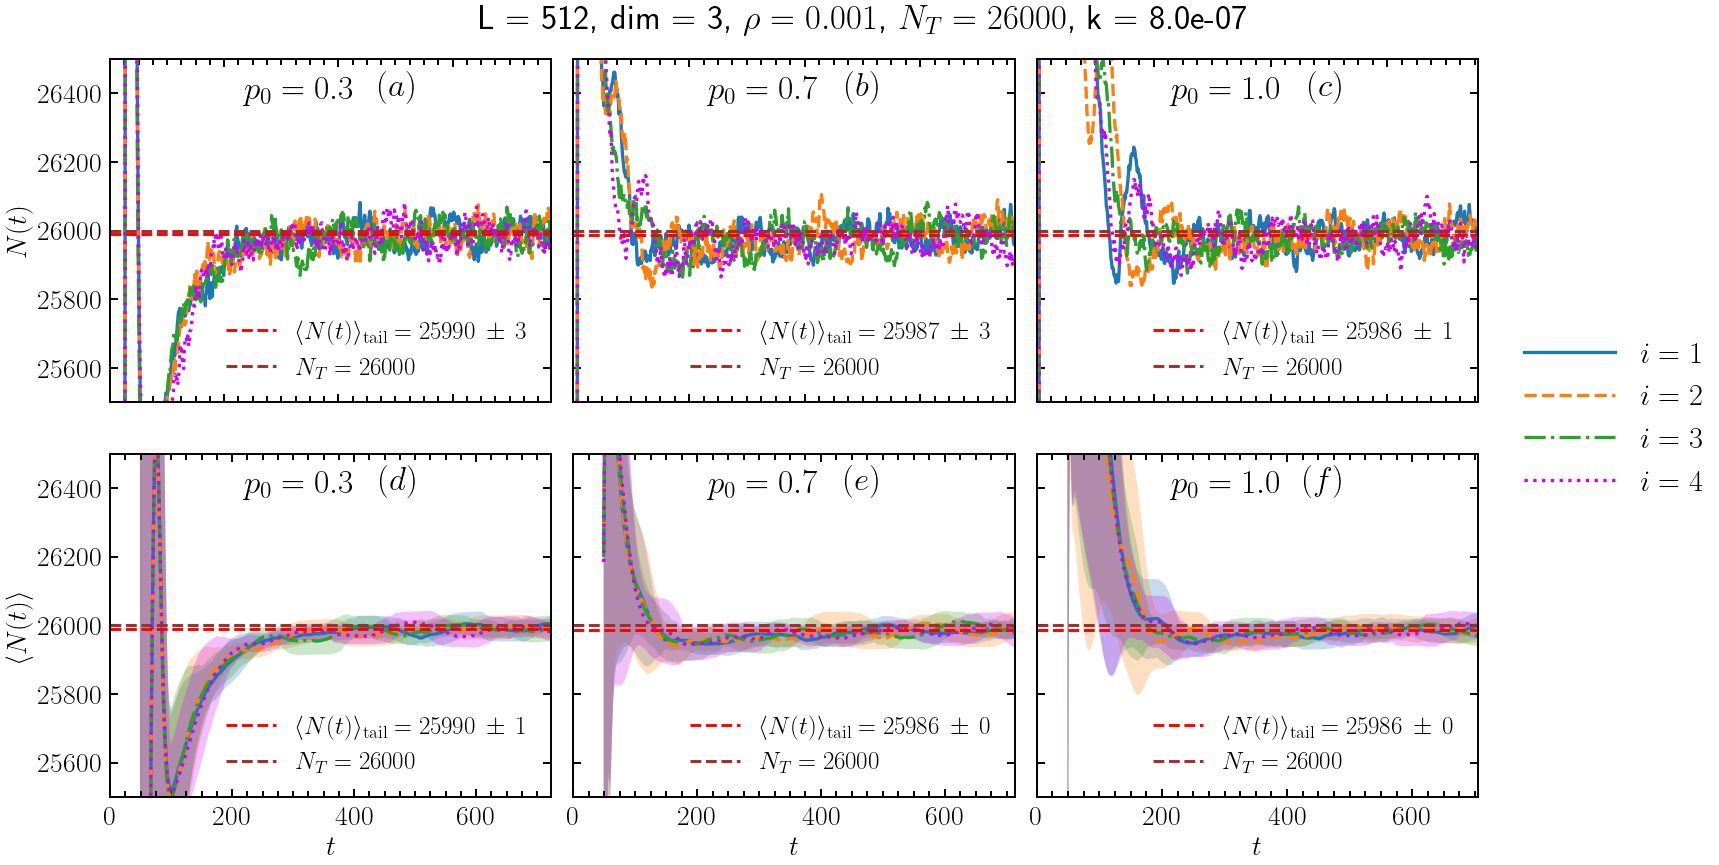

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ================== helpers ==================
def tail_mean(arr, tail_frac=0.3):
    a = np.asarray(arr, dtype=float)
    if a.size == 0: return np.nan
    k = max(1, int(np.floor((1.0 - tail_frac) * a.size)))
    return np.nanmean(a[k:])

def bootstrap_mean_scalar(values, prop, n_boot=20000, ci=0.95, rng=None):
    v = np.asarray(values, dtype=float)
    v = v[np.isfinite(v)]
    if v.size == 0:
        return np.nan, np.nan, (np.nan, np.nan)
    rng = np.random.default_rng() if rng is None else rng
    boots = rng.choice(v, size=(n_boot, v.size), replace=True).mean(axis=1)
    mean = v.mean()
    se   = boots.std(ddof=1)
    al   = (1-ci)/2
    lo, hi = np.quantile(boots, [al, 1-al])
    return mean, se, (lo, hi)

def rolling_mean_std(t, y, window: int):
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    if window < 1 or window > len(y):
        raise ValueError("window fora do intervalo válido")
    c  = np.cumsum(np.insert(y, 0, 0.0))
    c2 = np.cumsum(np.insert(y*y, 0, 0.0))
    mean = (c[window:] - c[:-window]) / window
    var  = (c2[window:] - c2[:-window]) / window - mean**2
    std  = np.sqrt(np.clip(var, 0, None))
    t_center = t[(window-1)//2 : len(t) - window//2]
    return t_center, mean, std

# ================== parâmetros ==================
L = 512
dim = 3
k = 8.0e-07
rho = 1.0e-03
NT = 26000

orders     = [1,2,3,4]
p0_list    = [0.3, 0.7, 1.0]
colors     = ["#1f77b4", "#ff7f0e", "#2ca02c", "#cc00ff"]
linestyles = ['solid', 'dashed', 'dashdot', 'dotted']
fontsize_ticks = 20
font_labels    = 20
thickness      = 1.4

tail_frac = 0.30
n_boot    = 20000
ci        = 0.95
rng       = np.random.default_rng(12345)

labels_top = ["$(a)$", "$(b)$", "$(c)$"]
labels_bot = ["$(d)$", "$(e)$", "$(f)$"]
major_step = 200
minor_step = 25
window = 100

ymin, ymax = 25500,26500
# ================== figura 2x3 ==================
fig, axes = plt.subplots(2, 3, sharey=True, figsize=(18, 9),
                         gridspec_kw={'wspace': 0.05, 'hspace': 0.15})

common_handles = common_labels = None

# ------------------ LINHA DE CIMA: plot simples ------------------
for col in range(3):
    ax  = axes[0, col]
    p0  = p0_list[col]
    means_per_curve = []

    Tmin = min(len(p0_index[p0][i]['time']) for i in orders)

    for j, i in enumerate(orders):
        t  = np.asarray(p0_index[p0][i]['time'][:Tmin], dtype=float)
        nt = np.asarray(p0_index[p0][i]['nt']  [:Tmin], dtype=float)

        ax.plot(t, nt, ls=linestyles[j], color=colors[j],
                linewidth=1.7*thickness, label=rf"$i = {i}$")

        m_tail = tail_mean(nt, tail_frac=tail_frac)
        if np.isfinite(m_tail): means_per_curve.append(m_tail)

    if col == 0:
        common_handles, common_labels = ax.get_legend_handles_labels()

    # estética (sem label no x e sem números nos ticks do x)
    ax.xaxis.set_major_locator(MultipleLocator(major_step))
    ax.xaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks,
                   width=thickness, length=6, pad=6)
    ax.tick_params(axis="x", which="minor", width=thickness, length=4)
    ax.tick_params(axis='x', which='both', labelbottom=False)  # <<< esconde valores dos ticks do x
    ax.set_xlim([0, float(t.max())])
    ax.set_ylim([ymin, ymax])

    mean_nt, se_nt, _ = bootstrap_mean_scalar(means_per_curve, 'nt', n_boot, ci, rng)
    red = ax.axhline(y=mean_nt, xmin=0, xmax=1.0, color='red', ls='--',
                     lw=1.5*thickness,
                     label=rf"$\langle N(t)\rangle_{{\rm tail}} = {int(mean_nt)}\,\pm\,{int(se_nt)}$")
    brown = ax.axhline(y=NT, xmin=0, xmax=1.0, color='brown', ls='--',
                    lw=1.5*thickness,
                    label=rf"$N_T={NT}$")
    ax.legend(handles=[red, brown], loc='lower right', frameon=False, fontsize=18)

    ax.text(0.30, 0.95, rf"$p_0 = {p0:.1f}$", transform=ax.transAxes, ha="left", va="top", fontsize=24)
    ax.text(0.70, 0.870, labels_top[col], transform=ax.transAxes, ha="right", va="bottom", fontsize=24)

axes[0,0].set_ylabel(r"$N(t)$", fontsize=font_labels)

# ------------------ LINHA DE BAIXO: média móvel + faixa ±std ------------------
for col in range(3):
    ax  = axes[1, col]
    p0  = p0_list[col]
    means_per_curve = []

    Tmin = min(len(p0_index[p0][i]['time']) for i in orders)

    for j, i in enumerate(orders):
        t  = np.asarray(p0_index[p0][i]['time'][:Tmin], dtype=float)
        nt = np.asarray(p0_index[p0][i]['nt']  [:Tmin], dtype=float)

        w = min(window, len(nt) - 1) if len(nt) > 1 else 1
        tc, mu, sd = rolling_mean_std(t, nt, w)

        ax.plot(tc, mu, ls=linestyles[j], color=colors[j],
                linewidth=1.7*thickness, label=rf"$i = {i}$")
        ax.fill_between(tc, mu - sd, mu + sd, alpha=0.25, color=colors[j], linewidth=0)

        m_tail = tail_mean(mu, tail_frac=tail_frac)
        if np.isfinite(m_tail): means_per_curve.append(m_tail)

    # estética (com label no x e com valores dos ticks)
    ax.set_xlabel("$t$", fontsize=font_labels)   # <<< somente na linha de baixo
    ax.xaxis.set_major_locator(MultipleLocator(major_step))
    ax.xaxis.set_minor_locator(MultipleLocator(minor_step))
    ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks,
                   width=thickness, length=6, pad=6)
    ax.tick_params(axis="x", which="minor", width=thickness, length=4)
    ax.set_xlim([0, float(tc.max() if tc.size else 0)])
    ax.set_ylim([ymin, ymax])

    mean_nt, se_nt, _ = bootstrap_mean_scalar(means_per_curve, 'nt', n_boot, ci, rng)
    
    red = ax.axhline(y=mean_nt, xmin=0, xmax=1.0, color='red', ls='--',
                    lw=1.5*thickness,
                    label=rf"$\langle N(t)\rangle_{{\rm tail}} = {int(mean_nt)}\,\pm\,{int(se_nt)}$")
    brown = ax.axhline(y=NT, xmin=0, xmax=1.0, color='brown', ls='--',
                lw=1.5*thickness,
                label=rf"$N_T={NT}$")
    ax.legend(handles=[red, brown], loc='lower right', frameon=False, fontsize=18)

    ax.text(0.30, 0.95, rf"$p_0 = {p0:.1f}$", transform=ax.transAxes, ha="left", va="top", fontsize=24)
    ax.text(0.70, 0.870, labels_bot[col], transform=ax.transAxes, ha="right", va="bottom", fontsize=24)

axes[1,0].set_ylabel(r"$\langle N(t) \rangle$", fontsize=font_labels)

# -------- legenda global --------
fig.legend(common_handles, common_labels,
           loc='center left', bbox_to_anchor=(0.85, 0.52),
           frameon=False, ncol=1, fontsize=22, handlelength=3)

# -------- layout / título --------
fig.subplots_adjust(left=0.08, right=0.84, top=0.92, bottom=0.10, wspace=0.18, hspace=0.28)
fig.suptitle(rf"L = {L}, dim = {dim},  $\rho = {rho}$, $N_T = {NT}$, k = {k:.1e}",
             fontsize=25, fontweight="bold", y=0.98)

plt.savefig(results_folder + "/4colors_Nt_diff_p0.pdf", bbox_inches="tight")
plt.show()


In [12]:
import pandas as pd
# JOIN ALL DATA PROCESSING
type_perc = 'bond'
dim = 3

# 1) Ler convertendo "Null" para NaN
df_all_3d = pd.read_csv(
    f"../Data/{type_perc}_percolation/all_data_{dim}D.dat",
    sep="\t",
    na_values=["Null", "null", "NaN", "nan", ""]
)

# 2) (opcional) garantir numérico nas colunas de interesse
num_cols = ["rho","p0","order","num_samples","num_sample_perc",
            "pt_mean","pt_erro","nt_mean","nt_erro"]
for c in num_cols:
    if c in df_all_3d.columns:
        df_all_3d[c] = pd.to_numeric(df_all_3d[c], errors="coerce")

# 3) Filtrar linhas SEM NaN em pt_mean e nt_mean
df_clean_3d = df_all_3d.dropna(subset=["pt_mean","nt_mean"]).copy()


# ver somente um range de colunas
df_clean_3d

# Filtrar simulações onde todos percolam

,type_perc,num_colors,dim,L,Nt,k,rho,p0,order,num_samples,num_sample_perc,pt_mean,pt_erro,nt_mean,nt_erro,M_size_mean,M_size_erro,perc_rate
0,bond,1,3,128,1600,0.000010,1.000000,0.3,1,1,1,0.258624,0.000000,1596.745098,0.000000,6.135520e+05,0.000000,1.000
1,bond,1,3,128,1600,0.000010,1.000000,1.0,1,1001,1001,0.258528,0.000018,1597.241842,0.095660,6.744892e+05,900.077797,1.000
2,bond,1,3,256,6500,0.000003,1.000000,0.3,1,561,561,0.257911,0.000009,6500.489132,0.080683,5.340340e+06,5719.025296,1.000
3,bond,1,3,256,6500,0.000003,1.000000,0.7,1,500,500,0.257914,0.000010,6500.450169,0.087660,5.438791e+06,6174.521414,1.000
4,bond,1,3,256,6500,0.000003,1.000000,1.0,1,500,500,0.257923,0.000010,6500.453569,0.089325,5.519814e+06,6456.957771,1.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2919,bond,8,3,256,6500,0.000003,0.090218,1.0,3,500,407,1.000000,0.000000,185.542342,4.394476,2.719491e+05,6263.211721,0.814
2920,bond,8,3,256,6500,0.000003,0.090218,1.0,4,500,200,1.000000,0.000000,158.663874,5.178732,2.312952e+05,7811.394246,0.400
2921,bond,8,3,256,6500,0.000003,0.090218,1.0,5,500,54,1.000000,0.000000,139.506114,7.815782,1.987491e+05,10311.238676,0.108
2922,bond,8,3,256,6500,0.000003,0.090218,1.0,6,500,6,1.000000,0.000000,127.276833,17.364504,1.708048e+05,27765.640166,0.012


In [19]:
df_clean_3d[(df_clean_3d["num_colors"]==2) & (df_clean_3d["L"]==512)]

,type_perc,num_colors,dim,L,Nt,k,rho,p0,order,num_samples,num_sample_perc,pt_mean,pt_erro,nt_mean,nt_erro,M_size_mean,M_size_erro,perc_rate
327,bond,2,3,512,26000,8.000000e-07,0.000010,1.0,1,50,50,0.386498,0.000060,26000.367218,0.447874,NaN,NaN,1.0
328,bond,2,3,512,26000,8.000000e-07,0.000010,1.0,2,50,50,0.386401,0.000062,25999.682106,0.407337,NaN,NaN,1.0
329,bond,2,3,512,26000,8.000000e-07,0.000015,1.0,1,50,50,0.386405,0.000056,26000.316084,0.476774,NaN,NaN,1.0
330,bond,2,3,512,26000,8.000000e-07,0.000015,1.0,2,50,50,0.386490,0.000048,25998.792603,0.464347,NaN,NaN,1.0
331,bond,2,3,512,26000,8.000000e-07,0.000020,1.0,1,50,50,0.386408,0.000055,25999.645674,0.459890,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1156,bond,2,3,512,26000,8.000000e-07,0.494980,1.0,2,50,50,0.590688,0.000040,26002.588539,0.711815,NaN,NaN,1.0
1157,bond,2,3,512,26000,8.000000e-07,0.497490,1.0,1,50,50,0.593238,0.000041,26002.731390,0.588863,NaN,NaN,1.0
1158,bond,2,3,512,26000,8.000000e-07,0.497490,1.0,2,50,50,0.593315,0.000041,26001.749028,0.608098,NaN,NaN,1.0
1159,bond,2,3,512,26000,8.000000e-07,0.500000,1.0,1,50,50,0.595742,0.000039,26003.030775,0.562326,NaN,NaN,1.0


Valor de rho_max válido: 0.0


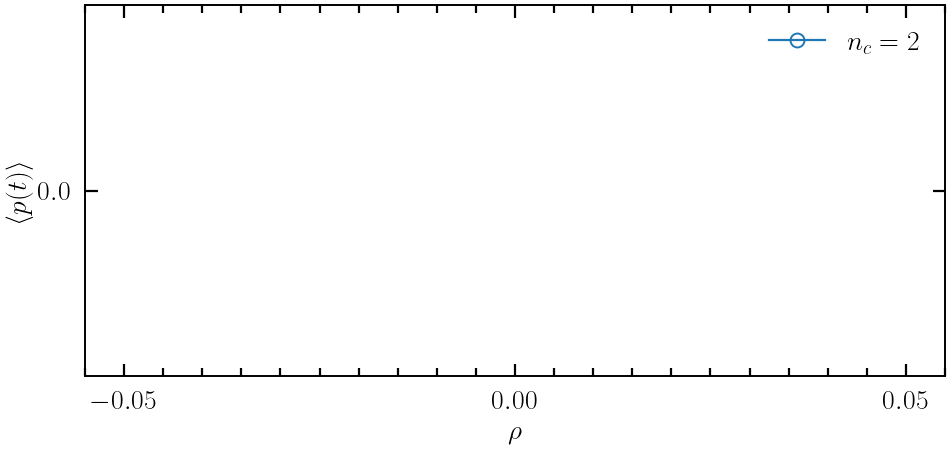

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.lines import Line2D
n_colors = [2]
fig, ax = plt.subplots(figsize=(10, 5))
for num_colors in n_colors:
    # ================== 1) Seleção, limpeza e reamostragem ==================
    # Filtrar os dados para num_colors = 4
    df_plot = df_clean_3d[(df_clean_3d["num_colors"] == num_colors) & (df_clean_3d["L"]==256)].copy()

    # Garantir que as colunas necessárias sejam numéricas
    for c in ["rho", "pt_mean", "pt_erro"]:
        if c in df_plot.columns:
            df_plot[c] = pd.to_numeric(df_plot[c], errors="coerce")

    # Remover valores nulos
    df_plot = df_plot.dropna(subset=["rho", "pt_mean"]).sort_values("rho")

    # ================== 2) Encontrar o valor máximo de rho válido para todos os orders ==================
    # Inicializar o valor de rho_max
    rho_max = 0.0

    # Verificar para cada valor de rho até onde existem dados válidos para cada order
    for rho in np.unique(df_plot["rho"]):
        # Filtrar os dados para o rho específico
        df_rho = df_plot[df_plot["rho"] == rho]
        
        # Verificar se todos os orders (1, 2, 3, 4) têm dados válidos
        valid_orders = df_rho["order"].unique()
        
        if all(order in valid_orders for order in [1, 2, 3, 4]):
            rho_max = rho

    # Mostrar o valor de rho_max encontrado
    print(f"Valor de rho_max válido: {rho_max}")

    # ================== 3) Plot ==================
    fontsize_ticks = 20
    font_labels     = 20
    ms              = 10
    thickness       = 1.6
    edge_width      = 1.4
    color_main      = "C0"   # cor da curva

    

    # Filtrar os dados para rho <= rho_max
    df_filtered = df_plot[df_plot["rho"] <= rho_max]

    # Plotar a curva para order = 1
    ax.plot(
        df_filtered["rho"], df_filtered["pt_mean"], "o-",
        lw=thickness,
        ms=ms,
        markerfacecolor='none',          # marcador SEM preenchimento
        markeredgecolor=color_main,      # contorno do marcador
        markeredgewidth=edge_width,
        label=f"$n_c = {num_colors}$",
        zorder=2
    )

# Labels, limites, grade
ax.set_xlabel(r"$\rho$", fontsize=font_labels)
ax.set_ylabel(r"$\langle p(t) \rangle$", fontsize=font_labels)

# Ticks principais e secundários
ax.xaxis.set_major_locator(MultipleLocator(0.05))
ax.xaxis.set_minor_locator(MultipleLocator(0.005))
ax.yaxis.set_major_locator(MultipleLocator(0.1))

ax.tick_params(axis="both", which="major",
               labelsize=fontsize_ticks, width=thickness, length=9, pad=10)
ax.tick_params(axis="x", which="minor", width=thickness, length=6)

# Legenda
ax.legend(frameon=False)

plt.tight_layout()

# Salvar (opcional): se 'savepath' existir, salva; caso contrário, só mostra
try:
    plt.savefig(results_folder + "/p_mean_X_rho_order_1.pdf", dpi=300)
    
except NameError:
    pass

plt.show()

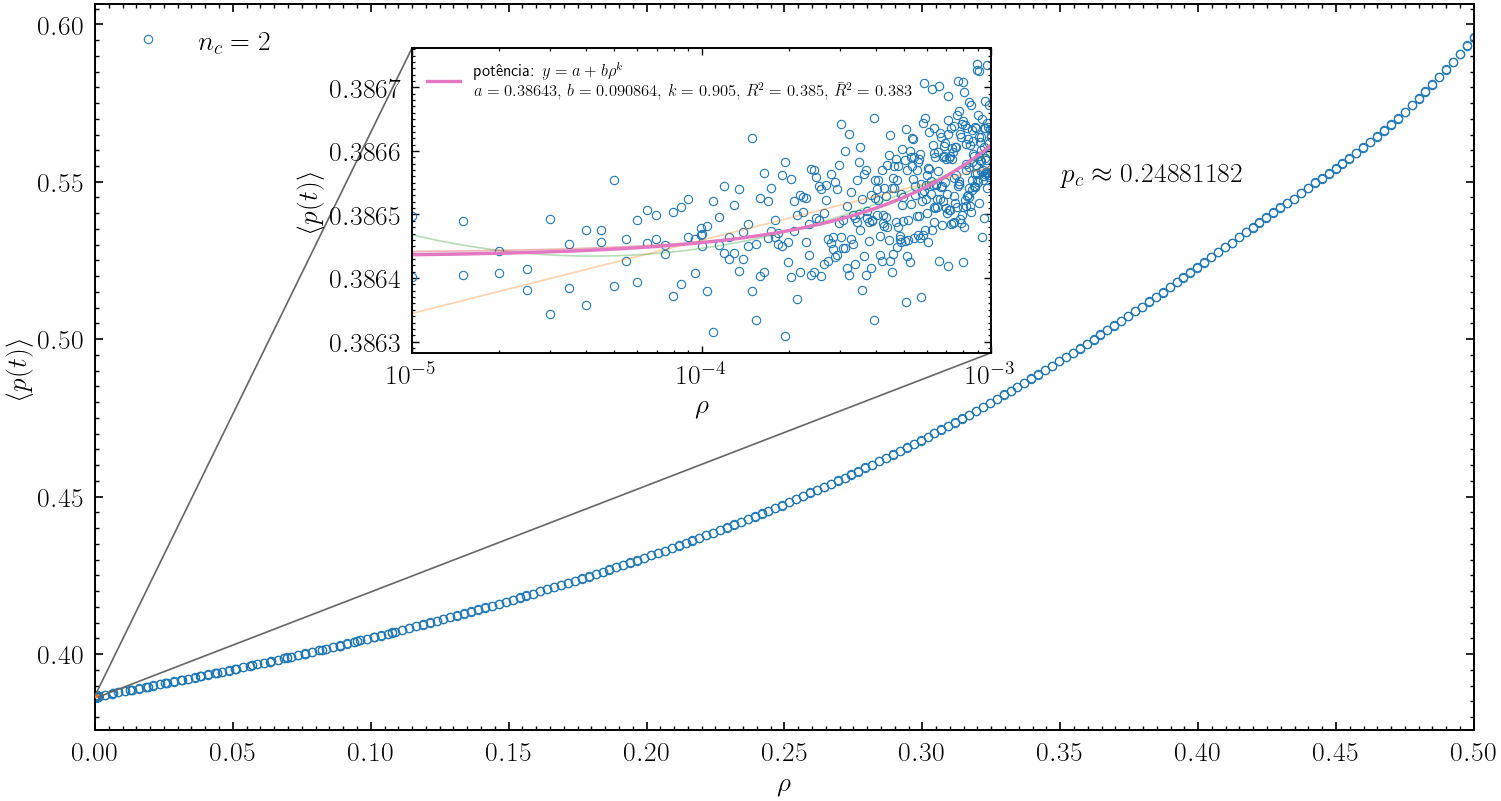

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
from matplotlib.ticker import MultipleLocator, AutoMinorLocator, MaxNLocator, LogLocator
# --- dados (seu filtro) ---
df_filter = df_clean_3d[(df_clean_3d["num_colors"] == 2) & (df_clean_3d["L"]==512)].copy()
df_filter = df_filter.dropna(subset=["rho", "pt_mean"]).sort_values("rho")

# --- figura principal (use constrained layout para evitar warning) ---
fig, ax = plt.subplots(figsize=(15, 8), layout='constrained')
ax.plot(df_filter["rho"], df_filter["pt_mean"], "o", ms=6, label=rf"$n_c=2$")
ax.set_xlim(0, 0.5)
ax.set_xlabel(r"$\rho$")
ax.set_ylabel(r"$\langle p(t) \rangle$")
ax.legend(frameon=False)

# --- região do zoom ---
x1, x2 = 1e-5, 1e-3
mask = (df_filter["rho"] >= x1) & (df_filter["rho"] <= x2)
sub   = df_filter[mask].copy()

# cria o inset (zoom)
axins = ax.inset_axes([0.23, 0.52, 0.42, 0.42], transform=ax.transAxes)

axins.set_xscale("log")
axins.set_xlim(x1, x2)
axins.set_xlabel(r"$\rho$")
axins.set_ylabel(r"$\langle p(t) \rangle$")
# define limites de y do inset
if not sub.empty:
    y_min, y_max = sub["pt_mean"].min(), sub["pt_mean"].max()
    pad = 0.06 * (y_max - y_min if y_max > y_min else 1.0)
    axins.set_ylim(y_min - pad, y_max + pad)
else:
    y_all = df_filter["pt_mean"].to_numpy()
    pad = 0.06 * (np.ptp(y_all) if np.ptp(y_all) > 0 else 1.0)
    axins.set_ylim(y_all.min() - pad, y_all.max() + pad)

# plota pontos no inset
axins.plot(df_filter["rho"], df_filter["pt_mean"], "o", ms=6)

# ====================== REGRESSÕES E ESCOLHA DO MELHOR ======================
def adj_r2(r2, n, p):
    denom = max(n - p - 1, 1)
    return 1.0 - (1.0 - r2) * (n - 1) / denom

def r2_score(y, yhat):
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - y.mean())**2)
    return np.nan if ss_tot == 0 else 1.0 - ss_res/ss_tot

best = None
candidates = []

if len(sub) >= 3:
    rho = sub["rho"].to_numpy()
    y   = sub["pt_mean"].to_numpy()
    n   = len(y)

    rho_fit = np.logspace(np.log10(x1), np.log10(x2), 400)

    # 1) y = a + b * log10(rho)
    x = np.log10(rho)
    b1, a1 = np.polyfit(x, y, 1)
    yhat1 = a1 + b1 * x
    r2_1  = r2_score(y, yhat1)
    candidates.append({
        "name": "lin_log",
        "p": 1,
        "params": (a1, b1),
        "predict": lambda rf: a1 + b1*np.log10(rf),
        "r2": r2_1,
        "r2_adj": adj_r2(r2_1, n, 1),
        "label": lambda r2, r2a: r"lin-log: $y=a+b\log_{10}\rho$"
                                 + "\n"
                                 + rf"$a={a1:.5g},\,b={b1:.5g},\,R^2={r2:.3f},\,\bar{{R}}^2={r2a:.3f}$"
    })

    # 2) y = a + b log10(rho) + c log10(rho)^2
    c2, b2, a2 = np.polyfit(x, y, 2)
    yhat2 = a2 + b2*x + c2*x**2
    r2_2  = r2_score(y, yhat2)
    candidates.append({
        "name": "quad_log",
        "p": 2,
        "params": (a2, b2, c2),
        "predict": lambda rf: a2 + b2*np.log10(rf) + c2*np.log10(rf)**2,
        "r2": r2_2,
        "r2_adj": adj_r2(r2_2, n, 2),
        "label": lambda r2, r2a: r"quad-log: $y=a+b\log_{10}\rho+c(\log_{10}\rho)^2$"
                                 + "\n"
                                 + rf"$a={a2:.5g},\,b={b2:.5g},\,c={c2:.5g},\,R^2={r2:.3f},\,\bar{{R}}^2={r2a:.3f}$"
    })

    # 3) y = a + b * rho
    b3, a3 = np.polyfit(rho, y, 1)
    yhat3 = a3 + b3 * rho
    r2_3  = r2_score(y, yhat3)
    candidates.append({
        "name": "lin_rho",
        "p": 1,
        "params": (a3, b3),
        "predict": lambda rf: a3 + b3*rf,
        "r2": r2_3,
        "r2_adj": adj_r2(r2_3, n, 1),
        "label": lambda r2, r2a: rf"lin-ρ: $y=a+b\rho$"
                                 + "\n"
                                 + rf"$a={a3:.5g},\,b={b3:.5g},\,R^2={r2:.3f},\,\bar{{R}}^2={r2a:.3f}$"
    })

    # 4) y = a + b rho + c rho^2
    c4, b4, a4 = np.polyfit(rho, y, 2)
    yhat4 = a4 + b4*rho + c4*rho**2
    r2_4  = r2_score(y, yhat4)
    candidates.append({
        "name": "quad_rho",
        "p": 2,
        "params": (a4, b4, c4),
        "predict": lambda rf: a4 + b4*rf + c4*rf**2,
        "r2": r2_4,
        "r2_adj": adj_r2(r2_4, n, 2),
        "label": lambda r2, r2a: rf"quad-ρ: $y=a+b\rho+c\rho^2$"
                                 + "\n"
                                 + rf"$a={a4:.5g},\,b={b4:.5g},\,c={c4:.5g},\,R^2={r2:.3f},\,\bar{{R}}^2={r2a:.3f}$"
    })

    # 5) y = a + b * rho^k  (busca de k)
    k_grid = np.linspace(0.1, 2.0, 60)
    best_k, best_r2k, best_ab = None, -np.inf, (np.nan, np.nan)
    for k in k_grid:
        z = rho**k
        b_, a_ = np.polyfit(z, y, 1)   # y = a + b*z
        yhat_  = a_ + b_*z
        r2k    = r2_score(y, yhat_)
        if r2k > best_r2k:
            best_r2k, best_k, best_ab = r2k, k, (a_, b_)
    a5, b5 = best_ab
    candidates.append({
        "name": "power_k",
        "p": 1,
        "params": (a5, b5, best_k),
        "predict": lambda rf, a=a5, b=b5, k=best_k: a + b*(rf**k),
        "r2": best_r2k,
        "r2_adj": adj_r2(best_r2k, n, 1),
        "label": lambda r2, r2a, a=a5, b=b5, k=best_k:
            r"potência: $y=a+b\rho^k$" + "\n"
            + rf"$a={a:.5g},\,b={b:.5g},\,k={k:.3f},\,R^2={r2:.3f},\,\bar{{R}}^2={r2a:.3f}$"
    })

    # escolher melhor por R² ajustado
    best = max(candidates, key=lambda c: c["r2_adj"])

    # --- plotar TODOS no inset (suave) e DESTAQUE para o vencedor ---
    for c in candidates:
        yfit_c = c["predict"](rho_fit)
        axins.plot(rho_fit, yfit_c, "-", lw=1.2, alpha=0.35)

    yfit_best = best["predict"](rho_fit)
    axins.plot(rho_fit, yfit_best, "-", lw=2.4, label=best["label"](best["r2"], best["r2_adj"]))
    axins.legend(frameon=False, fontsize=12, loc="best")

    # também desenha o vencedor no gráfico principal (apenas no intervalo [x1,x2])
    ax.plot(rho_fit, yfit_best, "-", lw=2.4, zorder=3)

# desenha retângulo/linhas ligando ao inset
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.4", lw=1.2)
ax.text(x=0.35, y=0.55, s=r'$p_c \approx 0.24881182$')


x0, x1 = ax.get_xlim()
ax.xaxis.set_major_locator(MultipleLocator((x1 - x0)/10.0))
# subticks nos eixos (aqui: 10 subdivisões -> 9 minor ticks entre majors)
ax.xaxis.set_minor_locator(AutoMinorLocator(10))
ax.yaxis.set_minor_locator(AutoMinorLocator(10))  # 10 subticks no eixo y (principal)

# ====== INSET (x log, y linear) ======
# majors no log-x (tente ~10 no total)
axins.xaxis.set_major_locator(LogLocator(base=10, numticks=10))
# minors por década (2..9) — padrão em log
axins.xaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10)))
# 10 subticks no eixo y do inset (linear)
axins.yaxis.set_minor_locator(AutoMinorLocator(10))

# (opcional) estilize tamanho dos ticks
ax.tick_params(which='major', length=6, width=1.2)
ax.tick_params(which='minor', length=3, width=1.0)
axins.tick_params(which='major', length=5, width=1.0)
axins.tick_params(which='minor', length=2.5, width=0.9)

plt.show()


## COMPARATION 3D - 2 COLORS VERSUS 1 COLOR

In [54]:
# Generate data with means
TYPE_PERC = "bond"
NUM_COLORS = [1,2]
DIM = 3
L = 512
NT = 26000
K = 8.0e-07
RHO = [1.0, 1.0e-05]
P0_LIST = [1.0]
for i in range(len(NUM_COLORS)):
    compute_means_for_folder(
        type_perc=TYPE_PERC,
        num_colors=NUM_COLORS[i],
        dim=DIM,
        L=L,
        NT=NT,
        k=K,
        rho=RHO[i],
        p0_list=P0_LIST,
    )

[ok] p0=1.00: 250 arquivos agregados
[salvo] ../Data/bond_percolation/num_colors_1/dim_3/L_512/NT_constant/NT_26000/k_8.0e-07/rho_1.0000e+00/properties_mean_bundle.json
[ok] p0=1.00: 50 arquivos agregados
[salvo] ../Data/bond_percolation/num_colors_2/dim_3/L_512/NT_constant/NT_26000/k_8.0e-07/rho_1.0000e-05/properties_mean_bundle.json


In [23]:
bundle_path_1_color = "../Data/bond_percolation/num_colors_1/dim_3/L_512/NT_constant/NT_26000/k_8.0e-07/rho_1.0000e+00/properties_mean_bundle.json"
bundle1, p0_index_1_color = load_bundle(bundle_path_1_color)

bundle_path_2_color = "../Data/bond_percolation/num_colors_2/dim_3/L_512/NT_constant/NT_26000/k_8.0e-07/rho_1.0000e-05/properties_mean_bundle.json"
bundle2, p0_index_2_colors = load_bundle(bundle_path_2_color)

# p0 disponíveis
print("p0 em num_colors=2:", list(p0_index_2_colors.keys()))

# orders disponíveis para p0=1.0
print("orders em p0=1.0 (nc=2):", list(p0_index_2_colors[1.0].keys()))

# o dicionário de dados do order=1 tem as séries:
print("chaves em p0=1.0, order=1:", list(p0_index_2_colors[1.0][1].keys()))
# esperado: ['time', 'pt', 'nt', 'Mt']  (dependendo do arquivo)


p0 em num_colors=2: [1.0]
orders em p0=1.0 (nc=2): [1, 2]
chaves em p0=1.0, order=1: ['time', 'pt', 'nt', 'Mt', 'Smax', 'Ni', 'chi', 'stats']


In [55]:
# -*- coding: utf-8 -*-
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

# ================== helpers ==================
def rolling_mean_std(t, y, window: int):
    """Média móvel simples + desvio padrão por janela (retorna no centro da janela)."""
    y = np.asarray(y, dtype=float)
    t = np.asarray(t, dtype=float)
    window = max(1, min(window, len(y)))
    if window == 1:
        return t, y, np.zeros_like(y)
    c  = np.cumsum(np.insert(y, 0, 0.0))
    c2 = np.cumsum(np.insert(y*y, 0, 0.0))
    mean = (c[window:] - c[:-window]) / window
    var  = (c2[window:] - c2[:-window]) / window - mean**2
    std  = np.sqrt(np.clip(var, 0, None))
    t_center = t[(window-1)//2 : len(t) - window//2]
    return t_center, mean, std

def tail_slice(arr, tail_frac=0.3):
    """Retorna apenas a fração final (cauda) do vetor."""
    a = np.asarray(arr, dtype=float)
    if a.size == 0:
        return a
    k = max(1, int(np.floor((1.0 - tail_frac) * a.size)))
    return a[k:]

def bootstrap_tail_mean(series, tail_frac=0.3, n_boot=20000, ci=0.95, rng=None):
    """Bootstrap da média da cauda (reamostrando pontos da cauda com reposição)."""
    tail = tail_slice(series, tail_frac=tail_frac)
    tail = tail[np.isfinite(tail)]
    if tail.size == 0:
        return np.nan, np.nan, (np.nan, np.nan)
    rng = np.random.default_rng() if rng is None else rng
    boots = rng.choice(tail, size=(n_boot, tail.size), replace=True).mean(axis=1)
    mean = tail.mean()
    se   = boots.std(ddof=1)
    al   = (1-ci)/2
    lo, hi = np.quantile(boots, [al, 1-al])
    return mean, se, (lo, hi)

def get_curve(p0_index, p0, order_key):
    """Recupera t e pt para dado p0 e order (order é int)."""
    rec = p0_index[p0][order_key]
    t  = np.asarray(rec["time"], dtype=float)
    pt = np.asarray(rec["pt"],   dtype=float)
    return t, pt

# ================== parâmetros do plot ==================
p0_target    = 1.0
plot_smoothed = True
window       = 100

tail_frac = 0.30
n_boot    = 20000
ci        = 0.95
rng       = np.random.default_rng(12345)

fontsize_ticks = 18
font_labels    = 20
thickness      = 1.4
major_step     = 200
minor_step     = 25

# cores e estilos
col_nc2 = ["#1f77b4", "#ff7f0e"]   # duas curvas (orders) para num_colors=2
ls_nc2  = ["solid", "dashed"]
col_nc1 = "#2ca02c"                # uma curva para num_colors=1
ls_nc1  = "dashdot"

# ================== seleção dinâmica de orders ==================
orders_nc2_all = sorted(list(p0_index_2_colors[p0_target].keys()))
orders_nc1_all = sorted(list(p0_index_1_color[p0_target].keys()))

# para num_colors=2, usar as duas primeiras ordens disponíveis
orders_nc2 = orders_nc2_all[:2] if len(orders_nc2_all) >= 2 else orders_nc2_all
# para num_colors=1, usar a primeira
order_nc1  = orders_nc1_all[0]

# ================== figura única ==================
fig, ax = plt.subplots(figsize=(10.5, 6.2))

# --- num_colors = 2 ---
# alinhar pelo comprimento mínimo entre as duas ordens escolhidas
curves_nc2 = []
minlen = None
for ordk in orders_nc2:
    t, pt = get_curve(p0_index_2_colors, p0_target, ordk)
    minlen = len(pt) if minlen is None else min(minlen, len(pt))
    curves_nc2.append((ordk, t, pt))
curves_nc2 = [(ordk, t[:minlen], pt[:minlen]) for (ordk, t, pt) in curves_nc2]

tails_pool_nc2 = []  # caudas concatenadas das duas curvas (para bootstrap pooled)
tmax_all = 0.0

for j, (ordk, t, pt) in enumerate(curves_nc2):
    if plot_smoothed:
        tc, mu, sd = rolling_mean_std(t, pt, window)
        ax.plot(tc, mu, ls=ls_nc2[j % len(ls_nc2)], color=col_nc2[j % len(col_nc2)],
                linewidth=1.7*thickness, label=rf"num_colors=2, order={ordk}")
        ax.fill_between(tc, mu - sd, mu + sd, alpha=0.18,
                        color=col_nc2[j % len(col_nc2)], linewidth=0)
        tails_pool_nc2.append(tail_slice(mu, tail_frac=tail_frac))
        tmax_all = max(tmax_all, float(tc.max()) if tc.size else 0.0)
    else:
        ax.plot(t, pt, ls=ls_nc2[j % len(ls_nc2)], color=col_nc2[j % len(col_nc2)],
                linewidth=1.7*thickness, label=rf"num_colors=2, order={ordk}")
        tails_pool_nc2.append(tail_slice(pt, tail_frac=tail_frac))
        tmax_all = max(tmax_all, float(t.max()) if t.size else 0.0)

# linha da cauda (bootstrap sobre a cauda pooled das duas curvas)
if len(tails_pool_nc2) > 0:
    pooled_nc2 = np.concatenate([x for x in tails_pool_nc2 if x.size > 0]) \
                 if any(x.size > 0 for x in tails_pool_nc2) else np.array([])
    mean_nc2, se_nc2, _ = bootstrap_tail_mean(pooled_nc2, tail_frac=1.0,  # 1.0 porque já passamos só a cauda
                                              n_boot=n_boot, ci=ci, rng=rng)
    if np.isfinite(mean_nc2):
        ax.axhline(y=mean_nc2, xmin=0, xmax=1.0, color="#cc0000", ls='--',
                   lw=1.5*thickness,
                   label=rf"tail ⟨p(t)⟩ (nc=2) = {mean_nc2:.5f} ± {se_nc2:.5f}")

# --- num_colors = 1 ---
t1, pt1 = get_curve(p0_index_1_color, p0_target, order_nc1)
if plot_smoothed:
    tc1, mu1, sd1 = rolling_mean_std(t1, pt1, window)
    ax.plot(tc1, mu1, ls=ls_nc1, color=col_nc1, linewidth=1.7*thickness,
            label=rf"num_colors=1, order={order_nc1}")
    ax.fill_between(tc1, mu1 - sd1, mu1 + sd1, alpha=0.18, color=col_nc1, linewidth=0)
    mean_nc1, se_nc1, _ = bootstrap_tail_mean(mu1, tail_frac=tail_frac,
                                              n_boot=n_boot, ci=ci, rng=rng)
    tmax_all = max(tmax_all, float(tc1.max()) if tc1.size else 0.0)
else:
    ax.plot(t1, pt1, ls=ls_nc1, color=col_nc1, linewidth=1.7*thickness,
            label=rf"num_colors=1, order={order_nc1}")
    mean_nc1, se_nc1, _ = bootstrap_tail_mean(pt1, tail_frac=tail_frac,
                                              n_boot=n_boot, ci=ci, rng=rng)
    tmax_all = max(tmax_all, float(t1.max()) if t1.size else 0.0)

if np.isfinite(mean_nc1):
    ax.axhline(y=mean_nc1, xmin=0, xmax=1.0, color="#006600", ls='--',
               lw=1.5*thickness,
               label=rf"tail ⟨p(t)⟩ (nc=1) = {mean_nc1:.7f} ± {se_nc1:.7f}")

# ================== estética ==================
ax.set_xlabel("$t$", fontsize=font_labels)
ax.set_ylabel(r"$p(t)$", fontsize=font_labels)

ax.xaxis.set_major_locator(MultipleLocator(major_step))
ax.xaxis.set_minor_locator(MultipleLocator(minor_step))
ax.tick_params(axis="both", which="major", labelsize=fontsize_ticks,
               width=thickness, length=6, pad=6)
ax.tick_params(axis="x", which="minor", width=thickness, length=4)

ax.set_xlim([0, tmax_all if tmax_all > 0 else None])

# (opcional) limite vertical similar ao da sua captura:
# ax.set_ylim([0.25, 0.40])

ax.legend(frameon=False, fontsize=14, handlelength=3, ncol=1, loc="lower right")

ax.set_title("Comparação $p(t)$ para $p_0=1.0$ — num_colors=2 vs 1\n"
             "L=512, dim=3, $N_T=26000$, $k=8.0\\times 10^{-7}$",
             fontsize=18, pad=10)

plt.tight_layout()
# plt.savefig("pt_comparison_p0_1.0_nc2_vs_nc1.pdf", bbox_inches="tight")
plt.show()


NameError: name 'p0_index_2_colors' is not defined